In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

from analyses.plot_style import paper_style

In [2]:
data = np.load("data/zscore/neural.npz")

In [3]:
pretty_names = {
    "inferred_physics": "Physics",
    "raw_frames": "Pixels",
    "fwd_render": "Percept",
    "hidden_acts": "Hidden\nstates",
}

In [4]:
block_names = json.loads(str(data["block_names_json"]))
block_sizes = data["block_sizes"]

In [5]:
block_data = {}
start = 0
for name, size in zip(block_names, block_sizes):
    block_data[name] = data["W"][:, start : start + size]
    start += size

In [6]:
block_W_norms_dict = {
    name: np.linalg.norm(W, axis=1) for name, W in block_data.items()
}

In [7]:
block_W_norms = np.stack([block_W_norms_dict[name] for name in block_names]).T
block_W_norms -= block_W_norms.mean(axis=0)
block_W_norms /= block_W_norms.std(axis=0)

In [8]:
block_W_norms.max(axis=0)

array([3.245747 , 2.8959794, 3.5960975, 3.3247595], dtype=float32)

In [26]:
block_W_norms[block_W_norms[:, 0].argmax(), :]

array([ 3.245747  , -0.25436926,  1.1040853 ,  1.152734  ], dtype=float32)

[Text(0.5, 0, 'Pixels'),
 Text(1.5, 0, 'Percept'),
 Text(2.5, 0, 'Hidden\nstates'),
 Text(3.5, 0, 'Physics')]

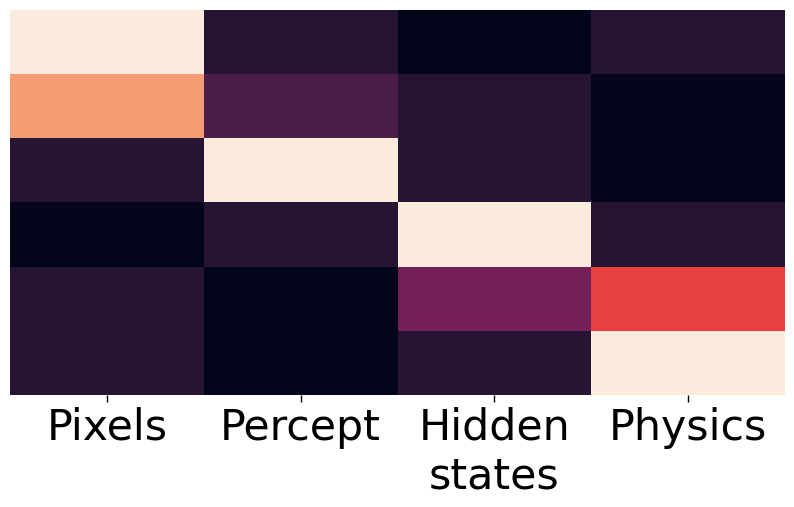

In [66]:
f, ax = plt.subplots(figsize=(10, 5))
ax = sns.heatmap(np.array([
    [1, 0.1, 0.0, 0.1],
    [0.8, 0.2, 0.1, 0.0],
    [0.1, 1, 0.1, 0.0],
    [0.0, 0.1, 1, 0.1],
    [0.1, 0.0, 0.3, 0.6],
    [0.1, 0.0, 0.1, 1],
]), xticklabels=[pretty_names.get(name, name) for name in block_names],
cbar=False)

ax.set_yticks([])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")

Text(0.5, 2.316666666666764, 'Feature block')

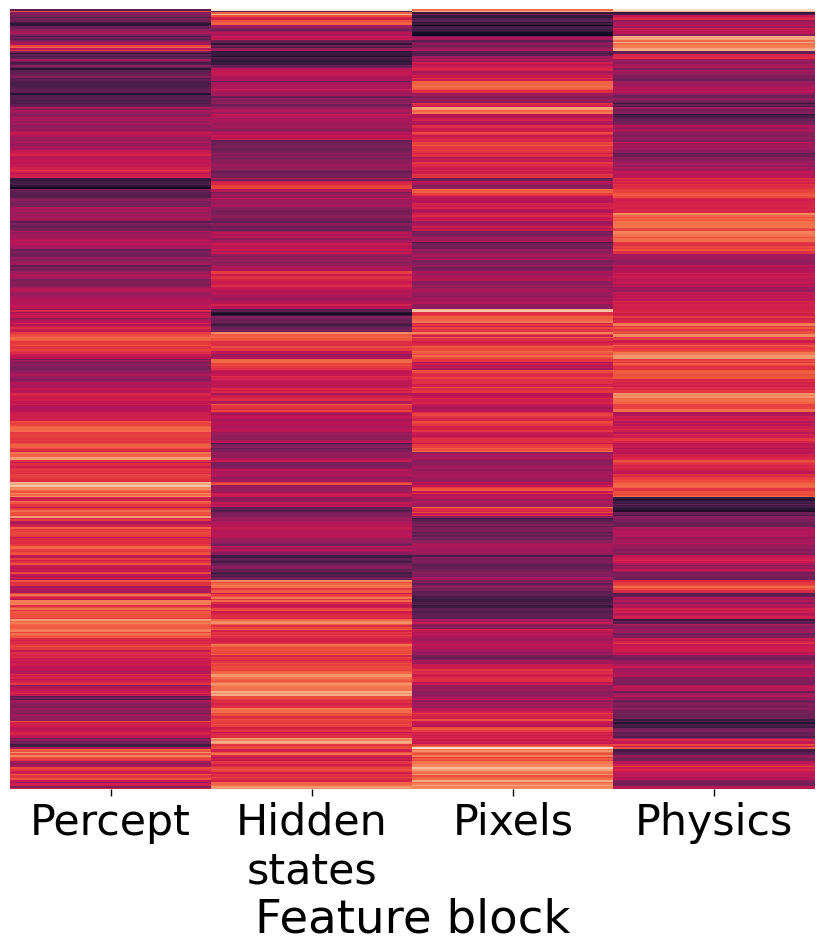

In [10]:
sns.set_context("paper", font_scale=3.5)
grid = sns.clustermap(
    block_W_norms,
    xticklabels=[pretty_names.get(name, name) for name in block_names],
    dendrogram_ratio=0.0001,

)
grid.cax.set_visible(False)
grid.ax_col_dendrogram.set_visible(False)
grid.ax_row_dendrogram.set_visible(False)
grid.ax_heatmap.yaxis.set_visible(False)
grid.ax_heatmap.set_xlabel("Feature block")